<a href="https://colab.research.google.com/github/Kevinlo937/cord-cutting-predicated/blob/main/topMSO_DL_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Load the required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Plot styling
import seaborn as sns; # sns.set()  # for plot styling
%matplotlib inline

In [2]:
myDatasetPath='csr_service_bill_enhanced.csv'
df = pd.read_csv(myDatasetPath)

In [3]:
# 檢查是否有任何空值
df.isnull().any()

CUST_NO                     False
使用狀態                        False
使用狀態_數值                     False
product_CM                  False
product_EPON                False
                            ...  
paymethod_其他繳款方式            False
paymethod_廠商代收              False
paymethod_當月繳帳單             False
paymethod_簡訊帳單臨櫃代收(7-11)    False
paymethod_金融機構轉帳            False
Length: 91, dtype: bool

In [ ]:
# ⚙️ 安裝套件
# !pip install -q imbalanced-learn

# 📚 載入套件
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, LSTM, InputLayer

# 📁 載入資料
# df = pd.read_csv("/content/csr_service_bill_enhanced.csv")

# 🧑‍💻 顯示基本狀態
print("資料筆數：", df.shape[0])
print("離退比例：")
print(df["使用狀態_數值"].value_counts(normalize=True))

# ✅ 資料清理與預處理
df = df.dropna().reset_index(drop=True)
y = df["使用狀態_數值"]

# 指定排除欄位
exclude_features = ['CUST_NO', '相關編號', '使用狀態','使用狀態_數值']

# 選擇 X 的特徵欄位 (排除指定欄位)
X = df.drop(columns=exclude_features)

# ⚖️ 標準化
X_scaled = MinMaxScaler().fit_transform(X)

# ⚠️ SMOTE 在切分前進行（會有資料洩漏風險，但可觀察最理想情況）
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_scaled, y)

# 🔀 切分資料集
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote)

# CNN / LSTM 輸入形狀 (samples, time_steps=features, channels=1)
X_train_seq = X_train.reshape(-1, X_train.shape[1], 1)
X_test_seq = X_test.reshape(-1, X_test.shape[1], 1)

# 🧠 MLP 模型
mlp_model = Sequential([
    InputLayer(input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🧠 CNN 模型
cnn_model = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🧠 LSTM 模型
lstm_model = Sequential([
    LSTM(32, input_shape=(X_train.shape[1], 1)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🏋️‍♂️ 模型訓練
print("訓練 MLP...")
mlp_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

print("\n訓練 CNN...")
cnn_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=1)

print("\n訓練 LSTM...")
lstm_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=1)

# 🔍 預測與比較
y_pred_mlp = (mlp_model.predict(X_test) > 0.5).astype(int)
y_pred_cnn = (cnn_model.predict(X_test_seq) > 0.5).astype(int)
y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype(int)

# 📊 評估報告
print("\n📊 MLP 分類報告：")
print(classification_report(y_test, y_pred_mlp))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_mlp))

print("\n📊 CNN 分類報告：")
print(classification_report(y_test, y_pred_cnn))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_cnn))

print("\n📊 LSTM 分類報告：")
print(classification_report(y_test, y_pred_lstm))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_lstm))


ModuleNotFoundError: No module named 'imblearn'

775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


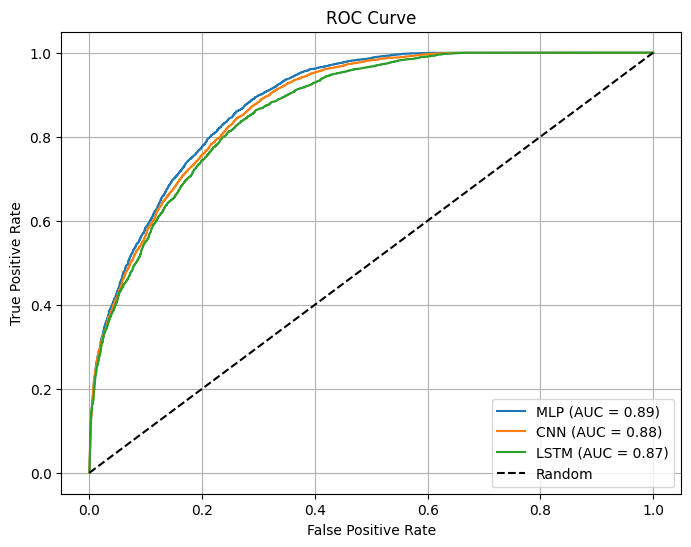

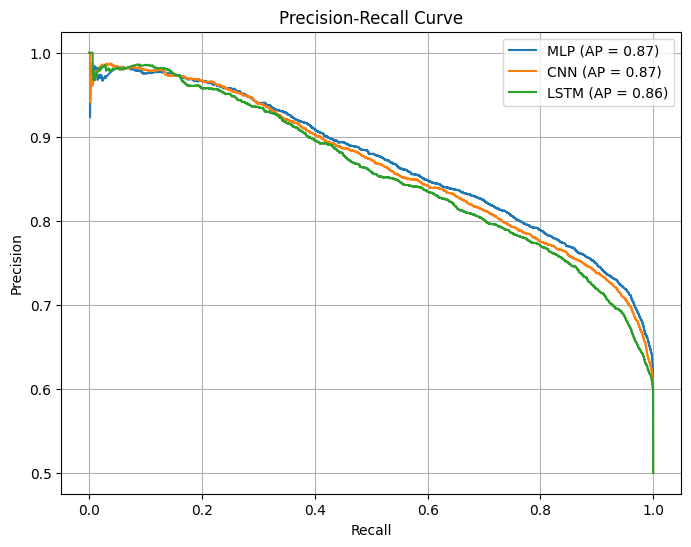

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 📊 計算每個模型的預測機率（注意：不是 >0.5 的結果）
y_score_mlp = mlp_model.predict(X_test).ravel()
y_score_cnn = cnn_model.predict(X_test_seq).ravel()
y_score_lstm = lstm_model.predict(X_test_seq).ravel()

# === ROC Curve ===
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_score_mlp)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_score_cnn)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_score_lstm)

auc_mlp = auc(fpr_mlp, tpr_mlp)
auc_cnn = auc(fpr_cnn, tpr_cnn)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {auc_mlp:.2f})")
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.2f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC = {auc_lstm:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# === PR Curve ===
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_score_mlp)
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, y_score_cnn)
precision_lstm, recall_lstm, _ = precision_recall_curve(y_test, y_score_lstm)

ap_mlp = average_precision_score(y_test, y_score_mlp)
ap_cnn = average_precision_score(y_test, y_score_cnn)
ap_lstm = average_precision_score(y_test, y_score_lstm)

plt.figure(figsize=(8, 6))
plt.plot(recall_mlp, precision_mlp, label=f"MLP (AP = {ap_mlp:.2f})")
plt.plot(recall_cnn, precision_cnn, label=f"CNN (AP = {ap_cnn:.2f})")
plt.plot(recall_lstm, precision_lstm, label=f"LSTM (AP = {ap_lstm:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, Dropout, Flatten, Dense

# 建立 CNN 模型（Functional API）
input_layer = Input(shape=(X_train.shape[1], 1))
x = Conv1D(32, kernel_size=2, activation='relu')(input_layer)
x = Dropout(0.2)(x)
x = Flatten()(x)
cnn_features = Dense(64, activation='relu', name='cnn_feature_layer')(x)
output_layer = Dense(1, activation='sigmoid')(cnn_features)

cnn_full_model = Model(inputs=input_layer, outputs=output_layer)
cnn_full_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 訓練模型
cnn_full_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=1)

# 擷取中間層（CNN learned features）
feature_extractor = Model(inputs=cnn_full_model.input,
                          outputs=cnn_full_model.get_layer('cnn_feature_layer').output)

X_train_feat = feature_extractor.predict(X_train_seq)
X_test_feat = feature_extractor.predict(X_test_seq)

# 建立 Random Forest 並分類
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_feat, y_train)

y_pred_rf = rf_model.predict(X_test_feat)

print("\n📊 CNN + Random Forest 分類報告：")
print(classification_report(y_test, y_pred_rf))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_rf))


Epoch 1/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7643 - loss: 0.4682
Epoch 2/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7771 - loss: 0.4418
Epoch 3/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7778 - loss: 0.4412
Epoch 4/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7799 - loss: 0.4359
Epoch 5/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7813 - loss: 0.4325
Epoch 6/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7833 - loss: 0.4323
Epoch 7/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7837 - loss: 0.4300
Epoch 8/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7876 - loss: 0.4248
Epoch 9/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7889 - loss: 0.4230
Epoch 10/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7877 - loss: 0.4245
Epoch 11/20
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7857 - loss: 0.4241
Epoch 12/20
3097/3097 ━━

In [7]:
# ** 提升 epoch 次數，比較結果 **

# ⚙️ 安裝套件
# !pip install -q imbalanced-learn

# 📚 載入套件
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, LSTM, InputLayer

# 📁 載入資料
df = pd.read_csv("/content/csr_service_bill.csv")

# 🧑‍💻 顯示基本狀態
print("資料筆數：", df.shape[0])
print("離退比例：")
print(df["使用狀態_數值"].value_counts(normalize=True))

# ✅ 資料清理與預處理
df = df.dropna().reset_index(drop=True)
y = df["使用狀態_數值"]

# 指定排除欄位
exclude_features = ['CUST_NO', '相關編號', '使用狀態_數值']

# 選擇 X 的特徵欄位 (排除指定欄位)
X = df.drop(columns=exclude_features)

# ⚖️ 標準化
X_scaled = MinMaxScaler().fit_transform(X)

# ⚠️ SMOTE 在切分前進行（會有資料洩漏風險，但可觀察最理想情況）
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_scaled, y)

# 🔀 切分資料集
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote)

# CNN / LSTM 輸入形狀 (samples, time_steps=features, channels=1)
X_train_seq = X_train.reshape(-1, X_train.shape[1], 1)
X_test_seq = X_test.reshape(-1, X_test.shape[1], 1)

# 🧠 MLP 模型
mlp_model = Sequential([
    InputLayer(input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🧠 CNN 模型
cnn_model = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🧠 LSTM 模型
lstm_model = Sequential([
    LSTM(32, input_shape=(X_train.shape[1], 1)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🏋️‍♂️ 模型訓練
print("訓練 MLP...")
mlp_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

print("\n訓練 CNN...")
cnn_model.fit(X_train_seq, y_train, epochs=100, batch_size=32, verbose=1)

print("\n訓練 LSTM...")
lstm_model.fit(X_train_seq, y_train, epochs=100, batch_size=32, verbose=1)

# 🔍 預測與比較
y_pred_mlp = (mlp_model.predict(X_test) > 0.5).astype(int)
y_pred_cnn = (cnn_model.predict(X_test_seq) > 0.5).astype(int)
y_pred_lstm = (lstm_model.predict(X_test_seq) > 0.5).astype(int)

# 📊 評估報告
print("\n📊 MLP 分類報告：")
print(classification_report(y_test, y_pred_mlp))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_mlp))

print("\n📊 CNN 分類報告：")
print(classification_report(y_test, y_pred_cnn))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_cnn))

print("\n📊 LSTM 分類報告：")
print(classification_report(y_test, y_pred_lstm))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_lstm))


資料筆數： 67249
離退比例：
使用狀態_數值
0.0    0.920787
1.0    0.079213
Name: proportion, dtype: float64
訓練 MLP...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7577 - loss: 0.4760
Epoch 2/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7784 - loss: 0.4376
Epoch 3/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7829 - loss: 0.4317
Epoch 4/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7864 - loss: 0.4258
Epoch 5/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7836 - loss: 0.4281
Epoch 6/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7903 - loss: 0.4213
Epoch 7/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7914 - loss: 0.4187
Epoch 8/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7906 - loss: 0.4177
Epoch 9/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7925 - loss: 0.4175
Epoch 10/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7932 - loss: 0.4152
Epoch 11/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7950 - loss: 0.4128
Epoch 12/100
3097/3097 ━━━

775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


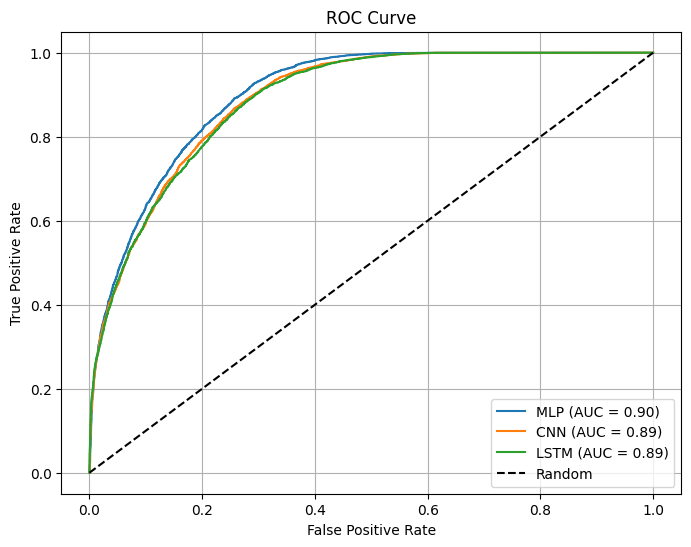

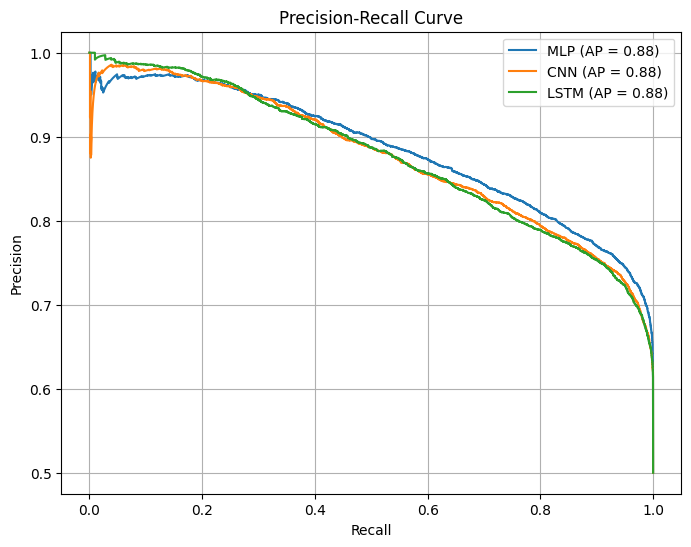

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 📊 計算每個模型的預測機率（注意：不是 >0.5 的結果）
y_score_mlp = mlp_model.predict(X_test).ravel()
y_score_cnn = cnn_model.predict(X_test_seq).ravel()
y_score_lstm = lstm_model.predict(X_test_seq).ravel()

# === ROC Curve ===
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_score_mlp)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_score_cnn)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_score_lstm)

auc_mlp = auc(fpr_mlp, tpr_mlp)
auc_cnn = auc(fpr_cnn, tpr_cnn)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {auc_mlp:.2f})")
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.2f})")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM (AUC = {auc_lstm:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# === PR Curve ===
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_score_mlp)
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, y_score_cnn)
precision_lstm, recall_lstm, _ = precision_recall_curve(y_test, y_score_lstm)

ap_mlp = average_precision_score(y_test, y_score_mlp)
ap_cnn = average_precision_score(y_test, y_score_cnn)
ap_lstm = average_precision_score(y_test, y_score_lstm)

plt.figure(figsize=(8, 6))
plt.plot(recall_mlp, precision_mlp, label=f"MLP (AP = {ap_mlp:.2f})")
plt.plot(recall_cnn, precision_cnn, label=f"CNN (AP = {ap_cnn:.2f})")
plt.plot(recall_lstm, precision_lstm, label=f"LSTM (AP = {ap_lstm:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, Dropout, Flatten, Dense

# 建立 CNN 模型（Functional API）
input_layer = Input(shape=(X_train.shape[1], 1))
x = Conv1D(32, kernel_size=2, activation='relu')(input_layer)
x = Dropout(0.2)(x)
x = Flatten()(x)
cnn_features = Dense(64, activation='relu', name='cnn_feature_layer')(x)
output_layer = Dense(1, activation='sigmoid')(cnn_features)

cnn_full_model = Model(inputs=input_layer, outputs=output_layer)
cnn_full_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 訓練模型
cnn_full_model.fit(X_train_seq, y_train, epochs=100, batch_size=32, verbose=1)

# 擷取中間層（CNN learned features）
feature_extractor = Model(inputs=cnn_full_model.input,
                          outputs=cnn_full_model.get_layer('cnn_feature_layer').output)

X_train_feat = feature_extractor.predict(X_train_seq)
X_test_feat = feature_extractor.predict(X_test_seq)

# 建立 Random Forest 並分類
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_feat, y_train)

y_pred_rf = rf_model.predict(X_test_feat)

print("\n📊 CNN + Random Forest 分類報告：")
print(classification_report(y_test, y_pred_rf))
print("混淆矩陣：\n", confusion_matrix(y_test, y_pred_rf))


Epoch 1/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7646 - loss: 0.4669
Epoch 2/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.7760 - loss: 0.4433
Epoch 3/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7816 - loss: 0.4371
Epoch 4/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7814 - loss: 0.4329
Epoch 5/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7805 - loss: 0.4338
Epoch 6/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7833 - loss: 0.4291
Epoch 7/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7862 - loss: 0.4261
Epoch 8/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7859 - loss: 0.4275
Epoch 9/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.7872 - loss: 0.4235
Epoch 10/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7879 - loss: 0.4219
Epoch 11/100
3097/3097 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7880 - loss: 0.4219
Epoch 12/100

In [12]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, LSTM, InputLayer

# 建立模型儲存目錄
os.makedirs('models/tensorflow', exist_ok=True)
# os.makedirs('models/preprocessing', exist_ok=True)

In [14]:
def save_models(mlp_model, cnn_model, lstm_model, cnn_rf_model):
    """儲存模型為 TensorFlow SavedModel 格式"""
    print("儲存模型...")

    # 儲存 MLP 模型
    # Add the .keras extension for the native Keras format
    save_model(mlp_model, 'models/tensorflow/mlp_model.keras')

    # 儲存 CNN 模型
    # Add the .keras extension for the native Keras format
    save_model(cnn_model, 'models/tensorflow/cnn_model.keras')

    # 儲存 LSTM 模型
    # Add the .keras extension for the native Keras format
    save_model(lstm_model, 'models/tensorflow/lstm_model.keras')

    # 儲存 CNN+RF 模型
    # The rf_model is a scikit-learn model, not a Keras model.
    # save_model is for Keras models. To save a scikit-learn model,
    # you should use a library like joblib or pickle.
    # We will comment out the save_model line for rf_model as it's incorrect usage.
    # save_model(cnn_rf_model, 'models/tensorflow/cnn_rf_model.keras')

    # To save the scikit-learn Random Forest model, use joblib:
    import joblib
    # Ensure the directory exists before saving the RF model
    os.makedirs('models/sklearn', exist_ok=True)
    joblib.dump(cnn_rf_model, 'models/sklearn/rf_model.joblib')
    print("Random Forest model (scikit-learn) saved using joblib.")

    print("Keras models saved successfully!")

# 儲存模型
# Pass the correct variable for the scikit-learn RF model
save_models(mlp_model, cnn_model, lstm_model, rf_model)

# Also update the zip command to include the sklearn models if desired
!zip -r models.zip models/

儲存模型...
Random Forest model (scikit-learn) saved using joblib.
Keras models saved successfully!
  adding: models/ (stored 0%)
  adding: models/.ipynb_checkpoints/ (stored 0%)
  adding: models/tensorflow/ (stored 0%)
  adding: models/tensorflow/lstm_model.keras (deflated 31%)
  adding: models/tensorflow/mlp_model.keras (deflated 32%)
  adding: models/tensorflow/cnn_model.keras (deflated 33%)
  adding: models/sklearn/ (stored 0%)
  adding: models/sklearn/rf_model.joblib (deflated 82%)
